# Solving the task optimization problem using Quasi-Newton methods
---

## Introduction

In paragliding competitions, pilots rely on their flight instruments to compute the shortest route to goal. Such a route is defined as being the shortest path intersecting each turnpoint circumference at least once, in a predefined order.
Given a current position and a set of remaining turnpoints, the task optimization problem is to find this shortest route and derive its attributes : total distance, consecutive legs distances and optimized points defining the route.

### Note

In the following, I propose a solution to the task optimization problem in two-dimensional Euclidean space, but the result can be applied to any space as long as the distance metric is properly defined. Namely, it can be used in real world task optimizations relying on FAI sphere or WGS84 ellipsoid spaces. A real-world example can be found in [igclib's repository](https://github.com/igclib/igclib).

## Example

The following task is given as an illustation of the problem.

![Task example](/assets/img/task_optimization/example_task.png)

The pilot is currently at the point labeled `Position`. To reach the goal, it must first cross all turnpoints circumferences in the predefined order : `TP1`, `TP2`, `TP3`, `TP4`, and then `Goal`. We want to compute the shortest path  satisfying the validation of the task, which is the route given below.

![Optimization example](/assets/img/task_optimization/example_opti.png)

## State of the art

This algorithm is usually implemented by exploiting geometrical properties the problem. As an example, one of these properties is described below.

* Consider three distinct consecutive turnpoints `TP1`, `TP2` and `TP3`.
The optimized point of `TP2` must lie at the intersection of its circumference and the bisector of the angle formed by the centers of these three turnpoints.

This geometrical approach yields correct results in the ideal case, where all the turnpoints have distinct centers, and where a valid path going straight to goal does not exist. These two assumptions are quite restrictive, as successive concentric turnpoints are quite common, and the possibility that the shortest path has to go *through* a turnpoint (thus crossing the circumference of a single turnpoint at two distant points) always exists. 

While it is certainly possible to create a set of rules identifying every corner case, it would be tedious and error-prone.

## A new approach

The proposed alternative considers the total distance of the shortest path as an objective function, and minimizes this function using [Quasi-Newton methods](https://en.wikipedia.org/wiki/Quasi-Newton_method). An example implementation is given in Python.

The objective function $f$ takes 3 $n$-dimensional fixed parameters, $n$ being the number of remaining turnpoints + 1 (the pilot's position is a necessarily an optimized point of the shortest path). These parameters completely define the task : $x$ and $y$ vectors represent the center coordinates of each turnpoint (including the current position) and $r$ represents the turpoints radii vector (current position have a radius of 0, though it doesn't really matter). The variable parameter of this objective function is $\theta$, a $n$-dimensional vector representing the angles from the turnpoints centers which define the optimized points locations on each turnpoint. 

If we consider the example given as illustration, we have
  
  
$$
\quad
x = \begin{bmatrix} 0 \\ 5 \\ 0 \\ 7 \\ 12 \\ 12 \end{bmatrix} \quad
y = \begin{bmatrix} 0 \\ 0 \\ 4 \\ 7 \\ 0 \\ 5 \end{bmatrix} \quad 
r = \begin{bmatrix} 0 \\ 2 \\ 1 \\ 2 \\ 1 \\ 0 \end{bmatrix} \quad
\theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \theta_2 \\ \theta_3 \\ \theta_4 \\ \theta_5 \end{bmatrix}
\quad
$$
  
  
And we are looking for the angles $\theta_0, \theta_1 \ldots \theta_n$  such that $f(\theta, x, y, r) = d$ with $d$ being a global minimum of $f$. To do so, we can use a Quasi-Newton method, which tweaks the $\theta$ coordinates until the computed distance $d$ reaches a minimum of $f$. 

## Python implementation

In [1]:
import numpy as np
from scipy.optimize import minimize
from taskopt_utils import optplot

The objective function in the two-dimensional Euclidean space is pretty simple : it computes the sum of the consecutive distances between the optimized points. The optimized points are computed using trigonometric projections.

In [2]:
def tasklen(θ, x, y, r):
    x_proj = x + r*np.sin(θ)
    y_proj = y + r*np.cos(θ)

    dists = np.sqrt(np.power(np.diff(x_proj), 2) + np.power(np.diff(y_proj), 2))

    return dists.sum()

We use `scipy`'s [BFGS solver](https://docs.scipy.org/doc/scipy-0.18.1/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize) to compute the minima of our objective function. All angles are in degrees, in range $[-180, 180]$, relative to the north direction of the y-axis. The `optplot` method simply draws the task along with the shortest route, by using the resulting angles to compute the optimized waypoints.

Objective function has been evaluated 104 times
Optimizer performed 11 iterations
Angles minimizing the objective function : ['0.00', '-69.52', '109.84', '-167.32', '-22.68', '0.00']


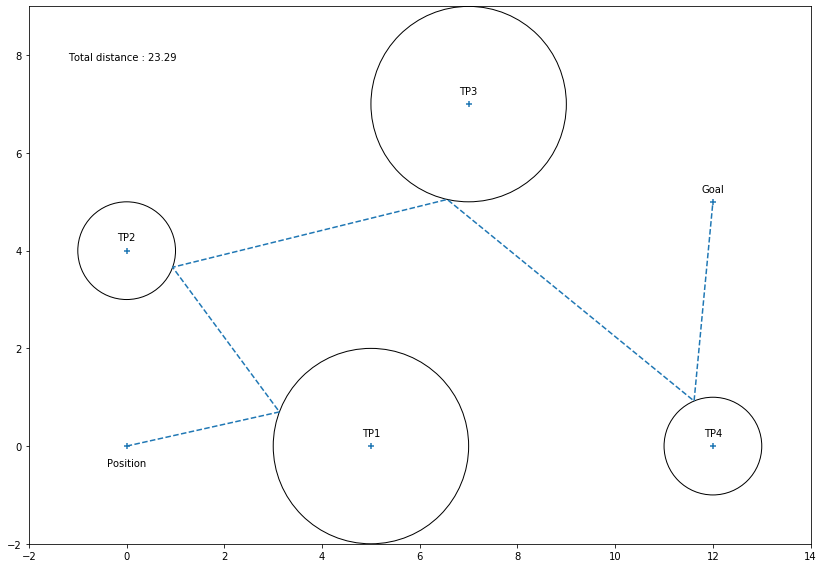

In [3]:
# center coordinates and radii of turnpoints
X = np.array([0, 5, 0, 7, 12, 12]).astype(float)
Y = np.array([0, 0, 4, 7, 0, 5]).astype(float)
R = np.array([0, 2, 1, 2, 1, 0]).astype(float)

# our first initialization vector is an array of zeros
init_vector = np.zeros(R.shape).astype(float)

result = minimize(tasklen, init_vector, args=(X, Y, R), tol=10e-5)
optplot(result, X, Y, R)

Now that we have computed the optimized angles a first time, we can use this result as an initialization vector for the next optimization, reducing the number of iterations needed to converge. When the pilots moves from one position to the next, the optimized angles are unlikely to drastically change so the computation time is reduced.

Objective function has been evaluated 56 times
Optimizer performed 3 iterations
Angles minimizing the objective function : ['0.00', '-69.05', '109.75', '-167.32', '-22.68', '0.00']


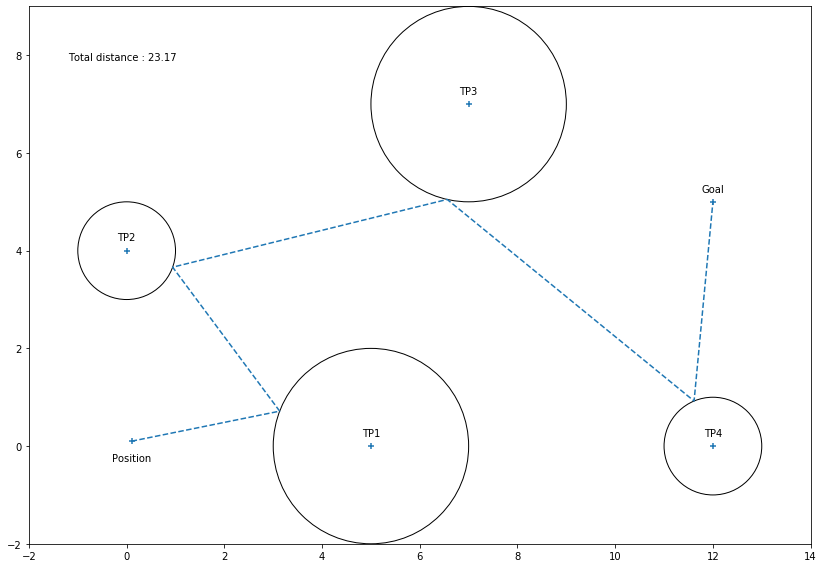

In [4]:
# the pilot slightly moves forward
X[0] = X[0] + 0.1
Y[0] = Y[0] + 0.1

# we use the last result as initialization vector
init_vector = result.x

result = minimize(tasklen, init_vector, args=(X, Y, R), tol=10e-5)
optplot(result, X, Y, R)

## Test cases 

Here are a few test cases showing the expected behaviour on tricky cases without any modifications to the algorithm. For the moment, the identified tricky cases are :
* successive concentric turnpoints
* direct line through a turnpoint

Objective function has been evaluated 168 times
Optimizer performed 15 iterations
Angles minimizing the objective function : ['0.00', '-166.21', '164.56', '157.72', '-68.48', '0.00']


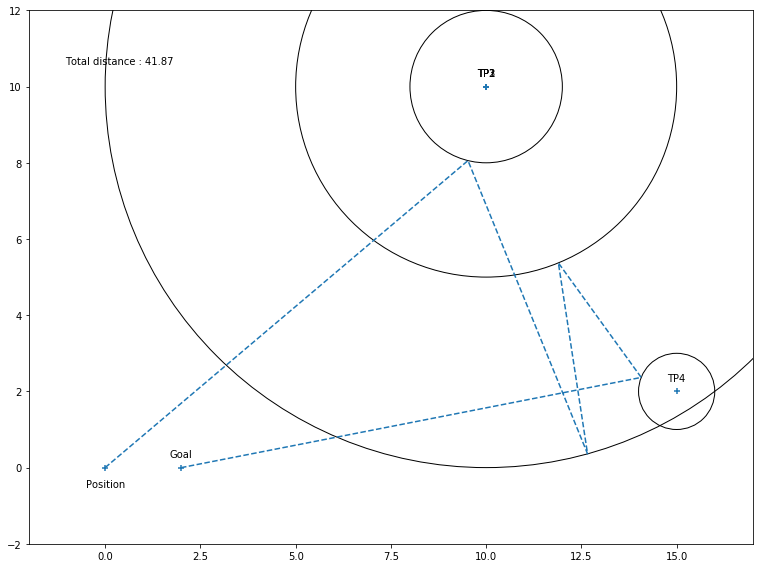

In [5]:
# concentric case
X = np.array([0, 10, 10, 10, 15, 2]).astype(float)
Y = np.array([0, 10, 10, 10, 2, 0]).astype(float)
R = np.array([0, 2, 10, 5, 1, 0]).astype(float)
init_vector = np.zeros(R.shape).astype(float)

result = minimize(tasklen, init_vector, args=(X, Y, R), tol=10e-5)
optplot(result, X, Y, R)

Objective function has been evaluated 120 times
Optimizer performed 10 iterations
Angles minimizing the objective function : ['0.00', '77.09', '-166.22', '8.09', '164.41', '0.00']


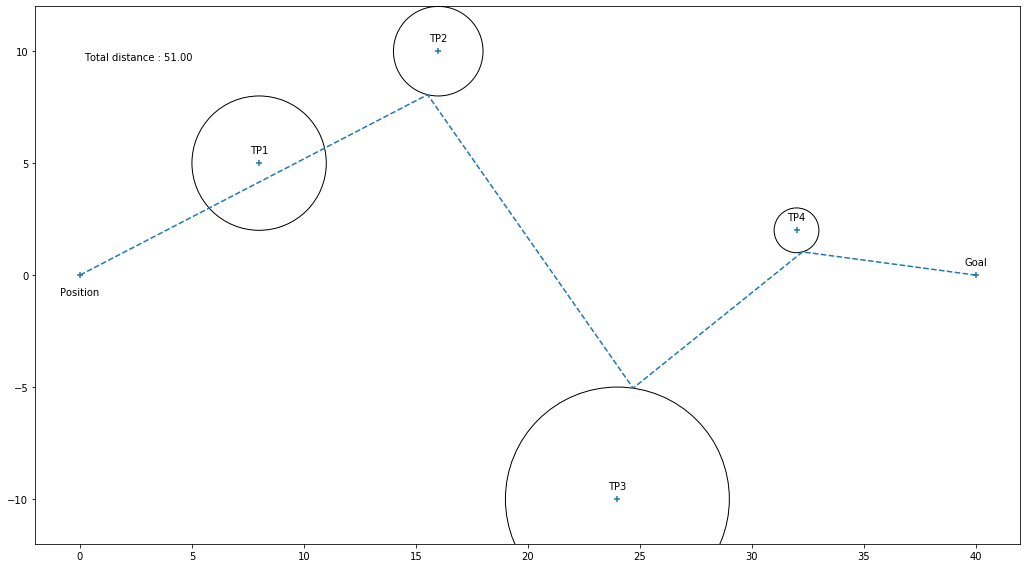

In [6]:
# direct line case
X = np.array([0, 8, 16, 24, 32, 40]).astype(float)
Y = np.array([0, 5, 10, -10, 2, 0]).astype(float)
R = np.array([0, 3, 2, 5, 1, 0]).astype(float)
init_vector = np.zeros(R.shape).astype(float)

result = minimize(tasklen, init_vector, args=(X, Y, R), tol=10e-5)
optplot(result, X, Y, R)

## Discussion 

This solution to the task optimization problem has the following advantages:

* only the first optimization is computationally expensive
* no assumption is made regarding the geometry of the task
* hyperparameters of the solvers can be tuned to converge faster for this specific problem
* it is quite concise, as long as you don't implement your own solver

However, it may have some flaws:

* if the solver converges towards a local minimum and not a global one, we would have to use [basinhopping](https://docs.scipy.org/doc/scipy-0.18.1/reference/generated/scipy.optimize.basinhopping.html#scipy.optimize.basinhopping) to find the global minimum, which is more expensive (such a case hasn't been observed yet)
* though this solution seems to yield acceptable results on small-scale examples, it hasn't been thoroughly tested yet, so feel free to play around with it and discover corner cases


This algorithm is going to be used in [igclib](https://github.com/teobouvard/igclib), a tool which will help in the analysis of paragliding competitions. It is a particularly efficient solution in this use case because we compute the remaing distance to goal for each pilot at each second of the flight, so the initialization vector trick allows us to have a reasonable performance.
If you have any suggestion, request or if you found a degenerate case, feel free to [send me a message](https://www.facebook.com/teobouvard/) or an email.

## Use this code 

All the above code is licensed under the GNU General Public License v3, which means you can use it for all purposes, as long as you disclose the source (*wink wink* @ XCTrack developpers).